In [22]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [23]:
data = {
    "Candidate_Name": [
        "Asha",
        "Rahul",
        "Priya",
        "Kiran",
        "Anjali"
    ],

    "Resume": [
        "Python machine learning SQL pandas data analysis",
        "HTML CSS JavaScript React Node js",
        "Python SQL Excel Power BI Tableau data visualization",
        "Java Python SQL OOP software development",
        "Python TensorFlow Keras deep learning NLP machine learning"
    ],

    "Job_Role": [
        "Data Scientist",
        "Web Developer",
        "Data Analyst",
        "Software Developer",
        "ML Engineer"
    ]
}

df = pd.DataFrame(data)

In [24]:

print("RESUME DATASET")
print(df)

RESUME DATASET
  Candidate_Name                                             Resume  \
0           Asha   Python machine learning SQL pandas data analysis   
1          Rahul                  HTML CSS JavaScript React Node js   
2          Priya  Python SQL Excel Power BI Tableau data visuali...   
3          Kiran           Java Python SQL OOP software development   
4         Anjali  Python TensorFlow Keras deep learning NLP mach...   

             Job_Role  
0      Data Scientist  
1       Web Developer  
2        Data Analyst  
3  Software Developer  
4         ML Engineer  


In [25]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text


df["Cleaned_Resume"] = df["Resume"].apply(preprocess)

print("\nCLEANED RESUMES")
print(df[["Candidate_Name", "Cleaned_Resume"]])


CLEANED RESUMES
  Candidate_Name                                     Cleaned_Resume
0           Asha   python machine learning sql pandas data analysis
1          Rahul                  html css javascript react node js
2          Priya  python sql excel power bi tableau data visuali...
3          Kiran           java python sql oop software development
4         Anjali  python tensorflow keras deep learning nlp mach...


In [26]:

skills = [
    "python",
    "sql",
    "machine learning",
    "pandas",
    "html",
    "css",
    "javascript",
    "react",
    "java",
    "excel",
    "power bi",
    "tableau",
    "tensorflow",
    "keras",
    "deep learning",
    "nlp"
]


def extract_skills(text):

    found = []

    for skill in skills:
        if skill in text:
            found.append(skill)

    return ", ".join(found)


df["Skills"] = df["Cleaned_Resume"].apply(extract_skills)

print("\nEXTRACTED SKILLS")
print(df[["Candidate_Name", "Skills"]])


EXTRACTED SKILLS
  Candidate_Name                                             Skills
0           Asha              python, sql, machine learning, pandas
1          Rahul                 html, css, javascript, react, java
2          Priya              python, sql, excel, power bi, tableau
3          Kiran                                  python, sql, java
4         Anjali  python, machine learning, tensorflow, keras, d...


In [27]:

required_skills = [
    "python",
    "machine learning",
    "sql",
    "pandas"
]


def match_score(text):

    count = 0

    for skill in required_skills:
        if skill in text:
            count += 1

    score = (count / len(required_skills)) * 100

    return score


df["Match_Score"] = df["Cleaned_Resume"].apply(match_score)

print("\nMATCH SCORES")
print(df[["Candidate_Name", "Match_Score"]])



MATCH SCORES
  Candidate_Name  Match_Score
0           Asha        100.0
1          Rahul          0.0
2          Priya         50.0
3          Kiran         50.0
4         Anjali         50.0


In [28]:
shortlisted = df[df["Match_Score"] >= 50]

print("\nSHORTLISTED CANDIDATES")
print(
    shortlisted[
        ["Candidate_Name", "Skills", "Match_Score"]
    ]
)



SHORTLISTED CANDIDATES
  Candidate_Name                                             Skills  \
0           Asha              python, sql, machine learning, pandas   
2          Priya              python, sql, excel, power bi, tableau   
3          Kiran                                  python, sql, java   
4         Anjali  python, machine learning, tensorflow, keras, d...   

   Match_Score  
0        100.0  
2         50.0  
3         50.0  
4         50.0  


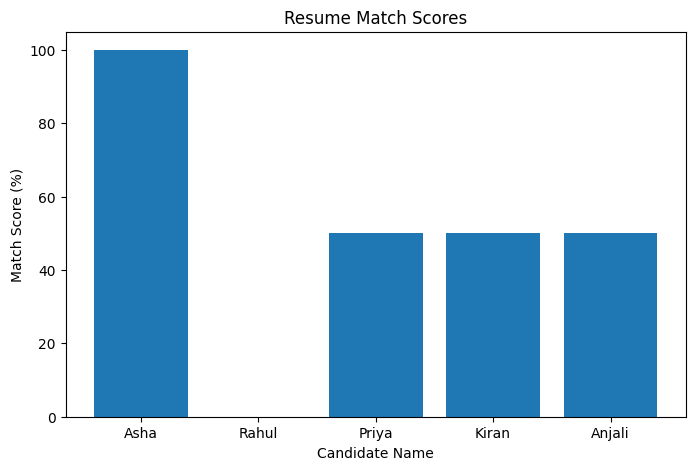

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    df["Candidate_Name"],
    df["Match_Score"]
)

plt.title("Resume Match Scores")
plt.xlabel("Candidate Name")
plt.ylabel("Match Score (%)")

plt.show()

In [30]:

shortlisted.to_csv(
    "shortlisted_candidates.csv",
    index=False
)

print("\nAnalysis Completed Successfully!")


Analysis Completed Successfully!
